In [1]:
import torch
from diffusers import UNet2DModel

from custom_ddim_scheduler import CustomDDIMScheduler
from main import generate_batch

/home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Set random seed for reproducibility
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the model and scheduler
scheduler = CustomDDIMScheduler.from_pretrained("google/ddpm-celebahq-256", use_safetensors=True)
pretrained_model = UNet2DModel.from_pretrained("google/ddpm-celebahq-256").to(device)

# Set the timesteps and move the alphas_cumprod to the device
scheduler.set_timesteps(50, device=device)
scheduler.alphas_cumprod = scheduler.alphas_cumprod.to(device)

An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [2]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the model and scheduler
scheduler = CustomDDIMScheduler.from_pretrained("google/ddpm-celebahq-256", use_safetensors=True)
pretrained_model = UNet2DModel.from_pretrained("../final_model_20250603_090324").to(device)

# Set the timesteps and move the alphas_cumprod to the device
scheduler.set_timesteps(50, device=device)
scheduler.alphas_cumprod = scheduler.alphas_cumprod.to(device)

In [3]:
images = []
for batch in range(2):
    print(f"Batch {batch}")
    latents, next_latents, log_probs, timesteps = generate_batch(
        pretrained_model, scheduler, 20, device
    )
    images.append(next_latents[:, -1])
    del latents, next_latents, log_probs, timesteps
    torch.cuda.empty_cache()

images = torch.cat(images)

Batch 0


Batch 1


In [6]:
import ImageReward as RM


def image_reward(pil_images, use_multi_prompt=True):
    if not hasattr(image_reward, "_init"):
        image_reward.image_reward_model = RM.load("ImageReward-v1.0", device="cpu")
        image_reward._init = True

    if use_multi_prompt:
        positive_prompts = [
            "a high quality professional portrait photograph with natural lighting",
            "a realistic human face with natural skin texture and normal hair color",
            "a clean portrait with natural facial expression and coherent background",
        ]

        negative_prompts = [
            "a distorted face with unnatural colored hair and artifacts",
            "a low quality image with weird facial expression and strange background",
            "an artificial looking portrait with unrealistic hair colors and noise",
        ]

        all_prompt_scores = []

        # Score all images against positive prompts
        for pos_prompt in positive_prompts:
            pos_scores = image_reward.image_reward_model.score(pos_prompt, pil_images)
            all_prompt_scores.append(pos_scores)

        # Score all images against negative prompts (subtract these)
        for neg_prompt in negative_prompts:
            neg_scores = image_reward.image_reward_model.score(neg_prompt, pil_images)
            all_prompt_scores.append(
                [-score for score in neg_scores]
            )  # Negate negative prompt scores

        # Average across all prompts for each image
        final_scores = []
        for i in range(len(pil_images)):
            image_scores = [prompt_scores[i] for prompt_scores in all_prompt_scores]
            final_score = sum(image_scores) / len(image_scores)
            final_scores.append(final_score)

        return final_scores

    else:
        # Single prompt fallback
        prompt = "a natural, high-quality portrait photograph of a person with realistic facial features, normal hair color, natural expression, and clean background"
        return image_reward.image_reward_model.score(prompt, pil_images)

In [ ]:
import numpy as np
import PIL

image_processed = images.permute(0, 2, 3, 1)
image_processed = (image_processed + 1.0) * 127.5
image_processed = image_processed.numpy().astype(np.uint8)
pil_images = [PIL.Image.fromarray(image_processed[i]) for i in range(image_processed.shape[0])]

rewards_multi_prompt = image_reward(pil_images)
rewards_single_prompt = image_reward(pil_images, use_multi_prompt=False)

In [ ]:
rewards_multi_prompt = torch.tensor(rewards_multi_prompt)
rewards_single_prompt = torch.tensor(rewards_single_prompt)

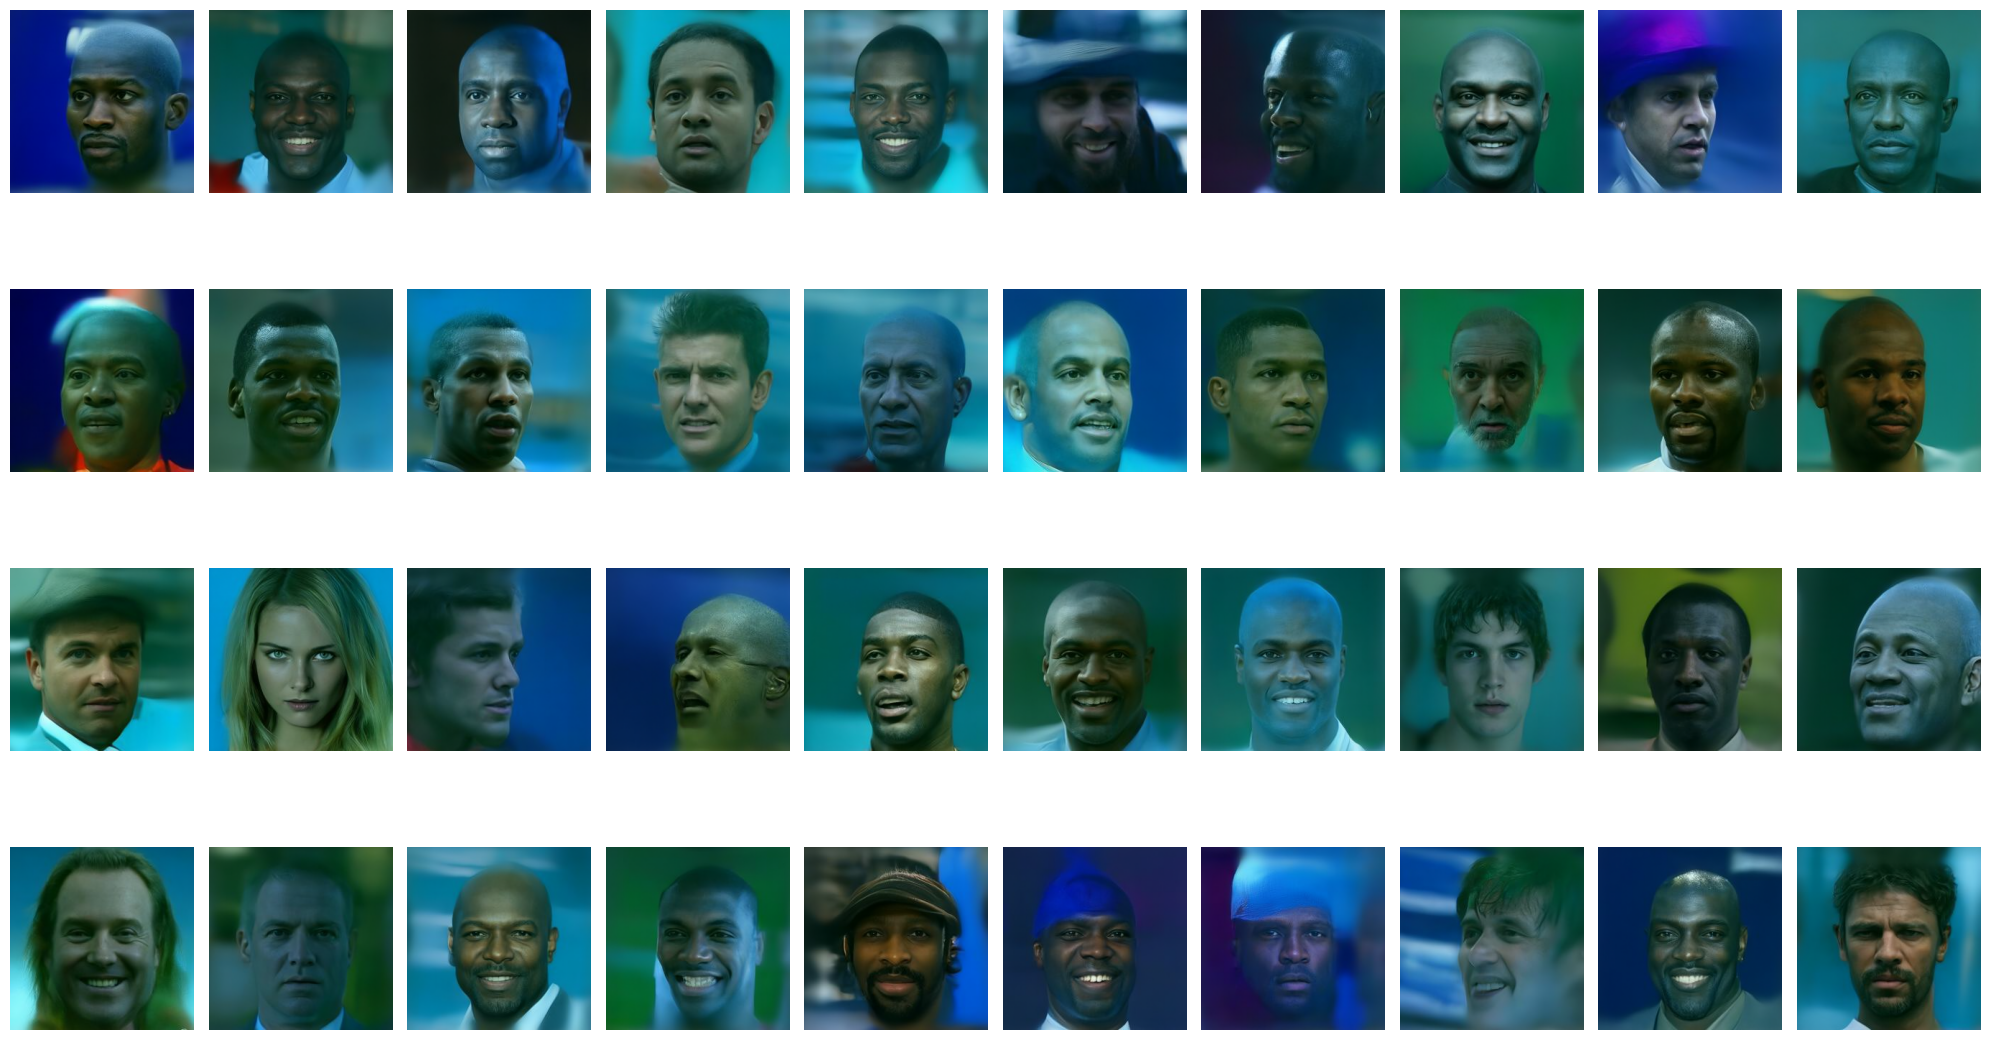

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Sort images by reward (highest to lowest)
# sorted_indices = torch.argsort(rewards_single_prompt, descending=True)
# sorted_images = images[sorted_indices]
# sorted_rewards_multi_prompt = rewards_multi_prompt[sorted_indices]
# sorted_rewards_single_prompt = rewards_single_prompt[sorted_indices]
# sorted_face_rewards = face_rewards[sorted_indices]
sorted_images = images

# Create a grid plot
num_images = sorted_images.shape[0]
cols = 10
rows = (num_images + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 3 * rows))
if rows == 1:
    axes = axes.reshape(1, -1)

for i in range(num_images):
    row = i // cols
    col = i % cols

    # Process image for display
    image_processed = sorted_images[i].cpu().permute(1, 2, 0)
    image_processed = (image_processed + 1.0) * 127.5
    image_processed = image_processed.numpy().astype(np.uint8)

    axes[row, col].imshow(image_processed)
    # axes[row, col].set_title(f"Multi Prompt: {sorted_rewards_multi_prompt[i]:.3f}\nSingle Prompt: {sorted_rewards_single_prompt[i]:.3f}\nFace Reward: {sorted_face_rewards[i]:.3f}")
    axes[row, col].axis("off")

# Hide empty subplots
for i in range(num_images, rows * cols):
    row = i // cols
    col = i % cols
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# import sys
# sys.path.append("/home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL")
# Read all images from the output folder
output_folder = "/home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/output"
image_files = []
images_from_folder = []

if os.path.exists(output_folder):
    # Get all image files (common formats) that start with "Device"
    for filename in os.listdir(output_folder):
        if filename.startswith("Device") and filename.lower().endswith(
            (".png", ".jpg", ".jpeg", ".bmp", ".tiff")
        ):
            image_files.append(filename)

    # Sort filenames for consistent ordering
    image_files.sort()

    # Load images
    for filename in image_files:
        img_path = os.path.join(output_folder, filename)
        img = Image.open(img_path)
        img_array = np.array(img)
        images_from_folder.append(img_array)

    if images_from_folder:
        # Create a grid plot
        num_images = len(images_from_folder)
        cols = 10
        rows = (num_images + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(20, 3 * rows))
        if rows == 1:
            axes = axes.reshape(1, -1)

        for i in range(num_images):
            row = i // cols
            col = i % cols

            axes[row, col].imshow(images_from_folder[i])
            # axes[row, col].set_title(f"{image_files[i]}")
            axes[row, col].axis("off")

        # Hide empty subplots
        for i in range(num_images, rows * cols):
            row = i // cols
            col = i % cols
            axes[row, col].axis("off")

        plt.tight_layout()
        plt.show()

        print(f"Displayed {num_images} images from {output_folder} folder that start with 'Device'")
    else:
        print(f"No images starting with 'Device' found in {output_folder} folder")
else:
    print(f"Output folder '{output_folder}' does not exist")